## First Step | Connect to a local mysql connection

Make a database if not already
Get list of Ticker, download the data

In [1]:
import sql_init
import stock_init

In [2]:
file_path = "sql_login.json"
DB_NAME = "asx_stock_data"
connection, mycursor = sql_init.connect_to_mysql(file_path, DB_NAME)

if connection is None:
    print("Failed to connect to MySQL database.")
print("Connected")

Connected


In [3]:
# Get the list of ticker symbols from db
query = """
SELECT *
FROM ticker_list
"""
mycursor.execute(query)
ticker_list = [i[0] for i in mycursor.fetchall()]

In [4]:
ticker_list[:5]

['AIA', 'ALL', 'AMC', 'ANZ', 'APA']

## Download data
Put download to **True** if we need to download more data

else **False**, this part only needed to be run every now and then

For the next downloads, specify the start date depending on the last date data we have

In [5]:
download = False
if download == True:
    for ticker in ticker_list:
        data = stock_init.download_ticker(ticker+".AX")
        sql_init.insert_stock_data(mycursor, ticker, data)
        connection.commit()

## Applying Financial Mathematical knowledge
Calculate returns

In [6]:
import pandas as pd
import numpy as np

In [7]:
# Get the list of ticker symbols from db
query = """
SELECT *
FROM stock_data
"""
mycursor.execute(query)
df = pd.DataFrame(mycursor.fetchall())
df.columns = ["symbol", "date", "close", "high", "low", "volume"]

In [8]:
df["log_return"] = df.groupby("symbol")["close"].transform(lambda x: np.log(x/x.shift(1)))

In [9]:
df.dtypes

symbol            str
date           object
close         float64
high          float64
low           float64
volume          int64
log_return    float64
dtype: object

In [10]:
df['date'] = pd.to_datetime(df['date'])

In [11]:
df.head()

,symbol,date,close,high,low,volume,log_return
0,AIA,2024-06-19,6.703379,6.732398,6.616323,579737,NaN
1,AIA,2024-06-20,6.771090,6.771090,6.655014,699062,0.010050
2,AIA,2024-06-21,6.858148,6.877494,6.732399,862134,0.012775
3,AIA,2024-06-24,6.829128,6.848474,6.761417,510947,-0.004240
4,AIA,2024-06-25,6.896839,6.925858,6.771090,615142,0.009866


#### Create trailing returns
Calculate the n-month trailing returns for every stock, and rank them

Find the top $20$% for every beginging of the month, this will show us which stocks to hold for any given month.
Test the strategy later.

In [12]:
# 12 month trailing momentum
df = stock_init.trailing_return(df, month=12)

In [13]:
df['rank'] = df.groupby('date')['momentum'].rank(pct=True)

In [14]:
first_days = df.groupby(df['date'].dt.to_period('M'))['date'].min()

In [15]:
monthly_first = df[df['date'].isin(first_days)]
monthly_first[monthly_first["rank"]>=0.8]

,symbol,date,close,high,low,volume,log_return,momentum,rank
792,ALL,2025-08-01,67.949707,69.265310,67.664987,1435722,-0.011921,0.342399,0.88
813,ALL,2025-09-01,69.098396,71.621597,69.098396,670886,-0.032570,0.310900,0.82
1915,ANZ,2026-01-02,35.598347,35.676544,35.393085,1661897,0.002199,0.327216,0.90
1935,ANZ,2026-02-02,35.920902,36.595334,35.832933,4390975,0.001361,0.279819,0.80
1955,ANZ,2026-03-02,38.442699,38.794575,37.836684,4559925,-0.017891,0.389918,0.86
...,...,...,...,...,...,...,...,...,...
23349,WDS,2026-06-01,30.670000,30.799999,30.080000,3576263,0.000326,0.466975,0.90
23690,WES,2025-10-01,89.688347,91.238955,89.401928,1131629,-0.013237,0.349421,0.88
23713,WES,2025-11-03,83.169868,83.337767,81.263707,1971677,0.002497,0.291797,0.82
25148,XRO,2025-07-01,182.029999,184.699997,180.160004,824480,0.012326,0.363214,0.80


#### Rolling Z-score
Find how far a stock is from it's mean of 20 days window

In [16]:
def rolling_z(window_size = 20):
    rolling_mean = df["close"].rolling(window_size).mean()
    rolling_std = df["close"].rolling(window_size).std()
    return (df["close"]-rolling_mean)/rolling_std

df["z_momentum"] = rolling_z(20)
df["z_reversion"] = rolling_z(252)

In [17]:
df.tail()

,symbol,date,close,high,low,volume,log_return,momentum,rank,z_momentum,z_reversion
25390,XRO,2026-06-15,73.349998,75.305000,73.349998,804195,-0.002043,-0.616891,0.061224,-1.272056,-1.229206
25391,XRO,2026-06-16,72.089996,73.489998,71.699997,655854,-0.017327,-0.627557,0.040816,-1.458253,-1.252498
25392,XRO,2026-06-17,74.580002,74.699997,70.175003,725286,0.033957,-0.611320,0.040816,-0.713103,-1.182528
25393,XRO,2026-06-18,71.639999,74.750000,71.260002,1075268,-0.040219,-0.630283,0.040816,-1.348432,-1.248380
25394,XRO,2026-06-19,70.199997,71.410004,70.195000,335166,-0.020305,-0.637134,0.040816,-1.528218,-1.276604


### Understand the difference between Momentum and Z-Momentum

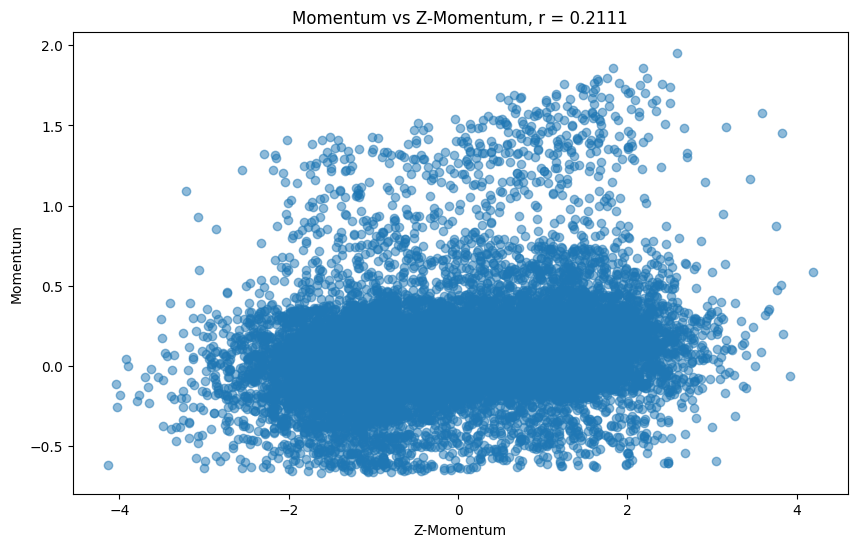

In [29]:
import matplotlib.pyplot as plt
from scipy import stats

fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(df["z_momentum"], df["momentum"], alpha=0.5)
ax.set_title("percentage Momentum vs z Momentum")

single_corr = df["z_momentum"].corr(df["momentum"])

ax.set_title(f"Momentum vs Z-Momentum, r = {single_corr:.4f}")
ax.set_ylabel("Momentum")
ax.set_xlabel("Z-Momentum")
plt.show()

Looking at the r score, and the graph, we can conclude that there ay be something different that they capture

- High raw momentum, low z-momentum — a stock that's just inherently volatile. A 30% move might be totally normal for it, so relative to its own history it isn't "unusual," even though the raw number looks big.
- Low raw momentum, high z-momentum — a normally very stable, low-volatility stock that moved 8%. Small in absolute terms, but huge relative to what that stock usually does.
- Regime changes — if a stock's volatility recently spiked or dropped, its rolling std shifts, which changes the z-score even if the raw return pattern looks similar to before

In [ ]:
sql_init.close_connection(connection)

: 